# BrainAge Federated Learning với BrainRotViT

Notebook này là bản chuyển đổi từ code ResNet-18/FedProx sang **BrainRotViT**.

Ý tưởng chính:
- Giữ pipeline dữ liệu `.pt` từ notebook `datasplit`.
- Thay `BrainAgeResNet18` bằng backbone **BrainRotViT = ViT slice encoder + Residual CNN regressor**.
- Mặc định **freeze ViT** và chỉ federate/train phần `proj + residual CNN + regression head` để giảm RAM/VRAM và giảm communication cost.
- Hỗ trợ tensor đầu vào dạng 2D slice `[N,C,H,W]` hoặc 3D volume/slice-stack `[N,S,C,H,W]`.

> Nếu dữ liệu `.pt` của bạn chỉ là ảnh 2D, notebook vẫn chạy bằng cách lặp lại ảnh thành `NUM_SLICES` pseudo-slices. Tuy nhiên, để đúng tinh thần BrainRotViT hơn, dữ liệu tốt nhất nên là MRI volume hoặc stack nhiều slice của cùng subject.


In [1]:
!pip install -q flwr torchvision timm einops

import os, math, warnings, gc
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset

import timm
import flwr as fl
from flwr.common import NDArrays, ndarrays_to_parameters, parameters_to_ndarrays
from flwr.server.strategy import FedAvg

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.1/857.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 

In [2]:
# =========================
# CONFIG
# =========================
NUM_CLIENTS  = 3
NUM_ROUNDS   = 50          # BrainRotViT nặng hơn ResNet, nên test 5-50 trước
LOCAL_EPOCHS = 1
LOCAL_LR     = 1e-4
BATCH_SIZE   = 2           # nếu OOM, giảm về 1
FEDPROX_MU   = 0.01        # với backbone lớn, bắt đầu nhỏ hơn 0.1

IMG_SIZE     = 224
NUM_SLICES   = 32          # nếu OOM, thử 8 hoặc 16
VIT_NAME     = "vit_base_patch16_224"
VIT_PRETRAINED = True
FREEZE_VIT   = True

# Chỉ truyền phần trainable qua Flower, không truyền ViT frozen
FEDERATE_TRAINABLE_ONLY = True

# Đường dẫn tới folder chứa tensors_client{cid}_train.pt, tensors_client{cid}_val.pt, tensors_test.pt
SPLIT_DIR = "/kaggle/input/datasets/phanhongdng/brainage-split"

SCANNER_NAMES = {0: "Siemens", 1: "Philips", 2: "GE"}

print("Config ready.")

Config ready.


In [3]:
def inspect_split_dir(split_dir: str):
    print("Files in split dir:")
    for fn in sorted(os.listdir(split_dir)):
        if fn.endswith(".pt"):
            p = os.path.join(split_dir, fn)
            try:
                obj = torch.load(p, map_location="cpu", weights_only=True)
                if isinstance(obj, dict) and "X" in obj and "y" in obj:
                    print(f"  {fn:<32} X={tuple(obj['X'].shape)} y={tuple(obj['y'].shape)}")
                else:
                    print(f"  {fn:<32} type={type(obj)}")
            except Exception as e:
                print(f"  {fn:<32} cannot inspect: {e}")

inspect_split_dir(SPLIT_DIR)

Files in split dir:
  tensors_client0_train.pt         X=(173, 3, 224, 224) y=(173,)
  tensors_client0_val.pt           X=(19, 3, 224, 224) y=(19,)
  tensors_client1_train.pt         X=(552, 3, 224, 224) y=(552,)
  tensors_client1_val.pt           X=(61, 3, 224, 224) y=(61,)
  tensors_client2_train.pt         X=(75, 3, 224, 224) y=(75,)
  tensors_client2_val.pt           X=(8, 3, 224, 224) y=(8,)
  tensors_test.pt                  X=(223, 3, 224, 224) y=(223,)


In [4]:
class BrainRotTensorDataset(Dataset):
    '''
    Dataset wrapper cho tensors .pt.

    Input hỗ trợ:
    - x sample [C,H,W]       từ X [N,C,H,W]
    - x sample [S,H,W]       từ X [N,S,H,W]
    - x sample [S,C,H,W]     từ X [N,S,C,H,W]

    Output luôn là:
    - slices: [S,3,IMG_SIZE,IMG_SIZE]
    - age: scalar float
    '''
    def __init__(
        self,
        X: torch.Tensor,
        y: torch.Tensor,
        num_slices: int = 32,
        img_size: int = 224,
        augment: bool = False,
    ):
        self.X = X
        self.y = y.float()
        self.num_slices = num_slices
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def _to_slice_stack(self, x: torch.Tensor) -> torch.Tensor:
        x = x.float()

        # Case 1: [C,H,W] hoặc [S,H,W]
        if x.ndim == 3:
            if x.shape[0] in (1, 3):
                # [C,H,W] -> [1,C,H,W]
                x = x.unsqueeze(0)
            else:
                # [S,H,W] -> [S,1,H,W]
                x = x.unsqueeze(1)

        # Case 2: [S,C,H,W]
        elif x.ndim == 4:
            # already [S,C,H,W]
            pass

        else:
            raise ValueError(f"Unsupported sample shape: {tuple(x.shape)}")

        # Đảm bảo channel ở dim=1
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        elif x.shape[1] != 3:
            raise ValueError(f"Expected channel 1 or 3 at dim=1, got shape {tuple(x.shape)}")

        # Chọn/pad số slices
        S = x.shape[0]
        if S >= self.num_slices:
            idxs = torch.linspace(0, S - 1, self.num_slices).long()
            x = x[idxs]
        else:
            # Nếu chỉ có 1 ảnh 2D, lặp lại thành pseudo-slices để model chạy được
            repeat_factor = math.ceil(self.num_slices / S)
            x = x.repeat(repeat_factor, 1, 1, 1)[:self.num_slices]

        # Resize từng slice về IMG_SIZE
        x = F.interpolate(
            x,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False,
        )

        # Augmentation nhẹ, dùng chung cho toàn bộ slice-stack
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[-1])  # horizontal flip

        return x

    def __getitem__(self, idx):
        x = self._to_slice_stack(self.X[idx])
        age = self.y[idx]
        return x, age


def make_loaders_from_tensors(split_dir: str, batch_size: int):
    print("Loading tensor datasets for BrainRotViT...")

    test_data = torch.load(f"{split_dir}/tensors_test.pt", map_location="cpu", weights_only=True)
    test_ds = BrainRotTensorDataset(
        test_data["X"], test_data["y"],
        num_slices=NUM_SLICES,
        img_size=IMG_SIZE,
        augment=False,
    )
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    print(f"  Test set            : {len(test_ds):5d} samples")

    client_loaders = {}
    centralized_train_datasets = []

    for cid in range(NUM_CLIENTS):
        t_data = torch.load(f"{split_dir}/tensors_client{cid}_train.pt", map_location="cpu", weights_only=True)
        t_ds = BrainRotTensorDataset(
            t_data["X"], t_data["y"],
            num_slices=NUM_SLICES,
            img_size=IMG_SIZE,
            augment=True,
        )
        t_loader = DataLoader(t_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
        centralized_train_datasets.append(t_ds)

        v_data = torch.load(f"{split_dir}/tensors_client{cid}_val.pt", map_location="cpu", weights_only=True)
        v_ds = BrainRotTensorDataset(
            v_data["X"], v_data["y"],
            num_slices=NUM_SLICES,
            img_size=IMG_SIZE,
            augment=False,
        )
        v_loader = DataLoader(v_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

        client_loaders[cid] = (t_loader, v_loader)
        print(f"  Client {cid} ({SCANNER_NAMES.get(cid, str(cid)):7s}): {len(t_ds):5d} train | {len(v_ds):5d} val")

    central_ds = ConcatDataset(centralized_train_datasets)
    centralized_loader = DataLoader(central_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    print(f"  Centralized train   : {len(central_ds):5d} samples")

    return client_loaders, centralized_loader, test_loader


client_loaders, centralized_loader, test_loader = make_loaders_from_tensors(SPLIT_DIR, BATCH_SIZE)

# Sanity check one batch
xb, yb = next(iter(centralized_loader))
print("Batch slices:", xb.shape, "| Batch ages:", yb.shape)
# Expected: [B, NUM_SLICES, 3, 224, 224]

Loading tensor datasets for BrainRotViT...
  Test set            :   223 samples
  Client 0 (Siemens):   173 train |    19 val
  Client 1 (Philips):   552 train |    61 val
  Client 2 (GE     ):    75 train |     8 val
  Centralized train   :   800 samples
Batch slices: torch.Size([2, 32, 3, 224, 224]) | Batch ages: torch.Size([2])


In [5]:
class ResidualBlock2D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(min(16, channels), channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(min(16, channels), channels),
        )
        self.act = nn.SiLU()

    def forward(self, x):
        return self.act(x + self.block(x))


def create_vit_encoder(vit_name: str, pretrained: bool):
    try:
        return timm.create_model(vit_name, pretrained=pretrained, num_classes=0)
    except Exception as e:
        print(f"[WARN] Cannot load pretrained={pretrained} for {vit_name}: {e}")
        print("[WARN] Falling back to pretrained=False.")
        return timm.create_model(vit_name, pretrained=False, num_classes=0)


class BrainRotViT(nn.Module):
    '''
    BrainRotViT tối giản:
    MRI slice stack [B,S,3,H,W]
      -> ViT encoder per slice
      -> feature map [B,1,S,768]
      -> Residual CNN regressor
      -> predicted brain age
    '''
    def __init__(
        self,
        vit_name: str = "vit_base_patch16_224",
        pretrained: bool = True,
        freeze_vit: bool = True,
        hidden_channels: int = 32,
        dropout: float = 0.25,
    ):
        super().__init__()

        self.vit = create_vit_encoder(vit_name, pretrained)
        embed_dim = self.vit.num_features

        if freeze_vit:
            for p in self.vit.parameters():
                p.requires_grad = False

        self.proj = nn.Sequential(
            nn.Conv2d(1, hidden_channels, kernel_size=3, padding=1),
            nn.GroupNorm(min(16, hidden_channels), hidden_channels),
            nn.SiLU(),
        )

        self.res_blocks = nn.Sequential(
            ResidualBlock2D(hidden_channels),
            ResidualBlock2D(hidden_channels),
            ResidualBlock2D(hidden_channels),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, 128),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
        )

        self._init_trainable_layers()

    def _init_trainable_layers(self):
        for m in list(self.proj.modules()) + list(self.res_blocks.modules()) + list(self.head.modules()):
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, slices: torch.Tensor) -> torch.Tensor:
        # slices: [B,S,3,H,W]
        B, S, C, H, W = slices.shape
        x = slices.reshape(B * S, C, H, W)

        # Nếu ViT freeze thì chạy no_grad để tiết kiệm VRAM
        vit_trainable = any(p.requires_grad for p in self.vit.parameters())
        with torch.set_grad_enabled(vit_trainable and self.training):
            feat = self.vit(x)  # [B*S, 768]

        feat = feat.reshape(B, S, -1)  # [B,S,768]
        feat = feat.unsqueeze(1)       # [B,1,S,768]

        z = self.proj(feat)
        z = self.res_blocks(z)
        z = self.pool(z)
        age = self.head(z).squeeze(1)
        return age


def make_model(pretrained: bool = VIT_PRETRAINED) -> BrainRotViT:
    return BrainRotViT(
        vit_name=VIT_NAME,
        pretrained=pretrained,
        freeze_vit=FREEZE_VIT,
        hidden_channels=32,
        dropout=0.25,
    )


def make_optimizer(model: nn.Module, base_lr: float) -> optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]
    return optim.AdamW(params, lr=base_lr, weight_decay=1e-4)


_tmp = make_model(pretrained=False)
print(f"Total params    : {sum(p.numel() for p in _tmp.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in _tmp.parameters() if p.requires_grad):,}")
del _tmp
gc.collect()
torch.cuda.empty_cache()

Total params    : 85,867,457
Trainable params: 68,801


In [6]:
# =========================
# Flower parameter helpers
# =========================

FED_PARAM_NAMES: Optional[List[str]] = None

def get_fed_param_names(model: nn.Module) -> List[str]:
    if not FEDERATE_TRAINABLE_ONLY:
        return list(model.state_dict().keys())

    # Chỉ federate các tensor tương ứng với trainable parameters/buffers ngoài ViT.
    trainable_names = {name for name, p in model.named_parameters() if p.requires_grad}
    names = []
    sd = model.state_dict()
    for name in sd.keys():
        # nhận cả parameter trainable và buffer của modules trainable nếu có
        if name in trainable_names:
            names.append(name)

    return names


def init_fed_param_names(model: nn.Module):
    global FED_PARAM_NAMES
    FED_PARAM_NAMES = get_fed_param_names(model)
    print(f"Federated tensors: {len(FED_PARAM_NAMES)}")
    for n in FED_PARAM_NAMES[:10]:
        print(" ", n)
    if len(FED_PARAM_NAMES) > 10:
        print("  ...")


def get_parameters(model: nn.Module) -> NDArrays:
    assert FED_PARAM_NAMES is not None, "Call init_fed_param_names(model) first."
    sd = model.state_dict()
    return [sd[name].detach().cpu().numpy() for name in FED_PARAM_NAMES]


def set_parameters(model: nn.Module, params: NDArrays) -> None:
    assert FED_PARAM_NAMES is not None, "Call init_fed_param_names(model) first."
    sd = model.state_dict()
    for name, value in zip(FED_PARAM_NAMES, params):
        sd[name] = torch.tensor(value, dtype=sd[name].dtype)
    model.load_state_dict(sd, strict=True)


def compute_metrics(model: nn.Module, loader: DataLoader) -> Tuple[float, float, float]:
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for imgs, ages in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            ages = ages.to(DEVICE, non_blocking=True)
            pred = model(imgs)
            preds.extend(pred.detach().cpu().numpy())
            targets.extend(ages.detach().cpu().numpy())

    p, y = np.array(preds), np.array(targets)
    mae  = float(np.mean(np.abs(p - y)))
    rmse = float(np.sqrt(np.mean((p - y) ** 2)))
    r2   = float(1 - np.sum((p - y) ** 2) / (np.sum((y - y.mean()) ** 2) + 1e-8))
    return mae, rmse, r2


def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, scheduler=None) -> float:
    model.train()
    criterion = nn.SmoothL1Loss(beta=5.0)
    total_mae, total_n = 0.0, 0

    for imgs, ages in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        ages = ages.to(DEVICE, non_blocking=True)

        pred = model(imgs)
        loss = criterion(pred, ages)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        optimizer.step()

        if scheduler:
            scheduler.step()

        with torch.no_grad():
            total_mae += torch.abs(pred.detach() - ages).sum().item()
        total_n += imgs.size(0)

    return total_mae / total_n if total_n else float("inf")


class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 0.05):
        self.patience = patience
        self.min_delta = min_delta
        self.best_mae = float("inf")
        self.counter = 0
        self.best_state = None
        self.stopped_at = 0

    def step(self, val_mae: float, model: nn.Module, epoch: int) -> bool:
        if val_mae < self.best_mae - self.min_delta:
            self.best_mae = val_mae
            self.counter = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.stopped_at = epoch
            return True
        return False

    def restore(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [7]:
print("\n" + "=" * 60)
print("  BASELINE – Centralized BrainRotViT")
print("=" * 60)

MAX_EPOCHS = max(5, min(30, NUM_ROUNDS * LOCAL_EPOCHS))

central_model = make_model(pretrained=VIT_PRETRAINED).to(DEVICE)
init_fed_param_names(central_model)

central_opt = make_optimizer(central_model, LOCAL_LR)
central_sched = optim.lr_scheduler.CosineAnnealingLR(
    central_opt,
    T_max=max(1, MAX_EPOCHS * len(centralized_loader)),
    eta_min=1e-6,
)

central_es = EarlyStopping(patience=8, min_delta=0.05)
central_history = {"epoch": [], "mae": [], "rmse": [], "r2": []}

for ep in range(1, MAX_EPOCHS + 1):
    train_mae = train_one_epoch(central_model, centralized_loader, central_opt, central_sched)
    mae, rmse, r2 = compute_metrics(central_model, test_loader)

    central_history["epoch"].append(ep)
    central_history["mae"].append(mae)
    central_history["rmse"].append(rmse)
    central_history["r2"].append(r2)

    print(f"  Ep {ep:03d} | train_MAE={train_mae:.3f} | test_MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

    if central_es.step(mae, central_model, ep):
        print(f"\n  Early stop @ epoch {ep} | best MAE={central_es.best_mae:.3f}")
        central_es.restore(central_model)
        break

central_mae, central_rmse, central_r2 = compute_metrics(central_model, test_loader)

print(f"\n  ✓ Centralized BrainRotViT → MAE: {central_mae:.3f} | RMSE: {central_rmse:.3f} | R²: {central_r2:.3f}")

torch.save(central_model.state_dict(), "/kaggle/working/centralized_brainrotvit.pth")
print("Saved → /kaggle/working/centralized_brainrotvit.pth")


  BASELINE – Centralized BrainRotViT


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Federated tensors: 34
  proj.0.weight
  proj.0.bias
  proj.1.weight
  proj.1.bias
  res_blocks.0.block.0.weight
  res_blocks.0.block.0.bias
  res_blocks.0.block.1.weight
  res_blocks.0.block.1.bias
  res_blocks.0.block.3.weight
  res_blocks.0.block.3.bias
  ...
  Ep 001 | train_MAE=11.467 | test_MAE=5.642 | RMSE=8.655 | R²=-0.004
  Ep 002 | train_MAE=6.899 | test_MAE=5.204 | RMSE=8.978 | R²=-0.081
  Ep 003 | train_MAE=6.666 | test_MAE=5.278 | RMSE=8.739 | R²=-0.024
  Ep 004 | train_MAE=6.669 | test_MAE=5.185 | RMSE=8.855 | R²=-0.051
  Ep 005 | train_MAE=6.633 | test_MAE=5.180 | RMSE=8.811 | R²=-0.041
  Ep 006 | train_MAE=6.686 | test_MAE=5.170 | RMSE=8.830 | R²=-0.045
  Ep 007 | train_MAE=6.509 | test_MAE=5.159 | RMSE=8.907 | R²=-0.064
  Ep 008 | train_MAE=6.574 | test_MAE=5.143 | RMSE=8.937 | R²=-0.071
  Ep 009 | train_MAE=6.468 | test_MAE=5.682 | RMSE=8.534 | R²=0.024
  Ep 010 | train_MAE=6.514 | test_MAE=5.076 | RMSE=8.835 | R²=-0.046
  Ep 011 | train_MAE=6.329 | test_MAE=5.320 | RM

In [8]:
class BrainAgeFedProxClient(fl.client.NumPyClient):
    def __init__(self, cid: int, train_loader: DataLoader, val_loader: DataLoader):
        self.cid = cid
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.model = make_model(pretrained=VIT_PRETRAINED).to(DEVICE)

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)

        # Lưu global params của phần federated/trainable để tính proximal loss
        global_named = {
            name: p.detach().clone()
            for name, p in self.model.named_parameters()
            if p.requires_grad
        }

        rnd = int(config.get("round_num", 1))
        current_lr = max(
            LOCAL_LR * (1 + math.cos(math.pi * (rnd - 1) / NUM_ROUNDS)) / 2,
            1e-6,
        )

        criterion = nn.SmoothL1Loss(beta=5.0)
        optimizer = make_optimizer(self.model, current_lr)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, LOCAL_EPOCHS * len(self.train_loader)),
            eta_min=1e-7,
        )

        self.model.train()
        total_mae, total_n = 0.0, 0

        for _ in range(LOCAL_EPOCHS):
            for imgs, ages in self.train_loader:
                imgs = imgs.to(DEVICE, non_blocking=True)
                ages = ages.to(DEVICE, non_blocking=True)

                pred = self.model(imgs)
                task_loss = criterion(pred, ages)

                prox_loss = 0.0
                for name, p in self.model.named_parameters():
                    if p.requires_grad:
                        prox_loss = prox_loss + ((p - global_named[name]) ** 2).sum()

                loss = task_loss + (FEDPROX_MU / 2.0) * prox_loss

                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_([p for p in self.model.parameters() if p.requires_grad], 1.0)
                optimizer.step()
                scheduler.step()

                with torch.no_grad():
                    total_mae += torch.abs(pred.detach() - ages).sum().item()
                total_n += imgs.size(0)

        avg_mae = total_mae / total_n if total_n else float("inf")
        print(f"    [C{self.cid}] train_MAE={avg_mae:.3f} | lr={current_lr:.2e}")

        # Flower cần trả về parameters, num_examples, metrics
        return get_parameters(self.model), len(self.train_loader.dataset), {"train_mae": avg_mae}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        mae, rmse, r2 = compute_metrics(self.model, self.val_loader)
        return float(mae), len(self.val_loader.dataset), {"mae": mae, "rmse": rmse, "r2": r2}

print("BrainAgeFedProxClient with BrainRotViT ready.")

BrainAgeFedProxClient with BrainRotViT ready.


In [9]:
class BrainRotFedProxStrategy(FedAvg):
    def __init__(self, global_model, test_loader, client_val_loaders, history, **kwargs):
        super().__init__(**kwargs)
        self.global_model = global_model.to(DEVICE)
        self.test_loader = test_loader
        self.client_val_loaders = client_val_loaders
        self.history = history
        self.best_mae = float("inf")
        self.best_state = None

    def aggregate_fit(self, server_round, results, failures):
        agg_params, metrics = super().aggregate_fit(server_round, results, failures)
        if agg_params is None:
            return agg_params, metrics

        set_parameters(self.global_model, parameters_to_ndarrays(agg_params))
        mae, rmse, r2 = compute_metrics(self.global_model, self.test_loader)

        self.history["round"].append(server_round)
        self.history["global_mae"].append(mae)
        self.history["global_rmse"].append(rmse)
        self.history["global_r2"].append(r2)

        if mae < self.best_mae:
            self.best_mae = mae
            self.best_state = {k: v.detach().cpu().clone() for k, v in self.global_model.state_dict().items()}

        per_str = []
        for cid, val_ldr in self.client_val_loaders.items():
            c_mae, _, _ = compute_metrics(self.global_model, val_ldr)
            self.history["per_client_mae"][cid].append(c_mae)
            per_str.append(f"C{cid}:{c_mae:.2f}")

        print(f"\n  [Round {server_round:03d}] Global MAE={mae:.3f} best={self.best_mae:.3f} | R²={r2:.3f} | " + " | ".join(per_str))

        gc.collect()
        torch.cuda.empty_cache()
        return agg_params, metrics

    def restore_best(self):
        if self.best_state is not None:
            self.global_model.load_state_dict(self.best_state)
            print(f"Restored best global model | MAE={self.best_mae:.3f}")

print("BrainRotFedProxStrategy ready.")

BrainRotFedProxStrategy ready.


In [10]:
# =========================
# Federated Learning Simulation
# =========================
# Lưu ý:
# - Nếu bị OOM, giảm NUM_SLICES, BATCH_SIZE, NUM_ROUNDS.
# - Nếu Ray object store lỗi trên Kaggle, restart session rồi chạy lại từ đầu.

try:
    import ray
    if ray.is_initialized():
        ray.shutdown()

    gc.collect()
    torch.cuda.empty_cache()

    ray.init(
        num_cpus=2,
        num_gpus=1 if torch.cuda.is_available() else 0,
        object_store_memory=3 * 1024 * 1024 * 1024,
        _system_config={
            "automatic_object_spilling_enabled": True,
            "max_direct_call_object_size": 100 * 1024 * 1024,
        },
        ignore_reinit_error=True,
    )
except Exception as e:
    print("[WARN] Ray init failed or unavailable:", e)

global_model = make_model(pretrained=VIT_PRETRAINED).to(DEVICE)
# FED_PARAM_NAMES đã init ở centralized cell. Nếu bạn skip centralized cell, uncomment dòng dưới:
# init_fed_param_names(global_model)

initial_params = ndarrays_to_parameters(get_parameters(global_model))
client_val_loaders = {cid: client_loaders[cid][1] for cid in range(NUM_CLIENTS)}

fl_history = {
    "round": [],
    "global_mae": [],
    "global_rmse": [],
    "global_r2": [],
    "per_client_mae": {cid: [] for cid in range(NUM_CLIENTS)},
}

strategy = BrainRotFedProxStrategy(
    global_model=global_model,
    test_loader=test_loader,
    client_val_loaders=client_val_loaders,
    history=fl_history,
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=initial_params,
    on_fit_config_fn=lambda rnd: {"round_num": rnd},
)

def client_fn(cid: str) -> fl.client.Client:
    gc.collect()
    torch.cuda.empty_cache()
    return BrainAgeFedProxClient(int(cid), *client_loaders[int(cid)]).to_client()

print("\n" + "=" * 70)
print("  FL Simulation – BrainRotViT + FedProx")
print(f"  Rounds={NUM_ROUNDS} | Clients={NUM_CLIENTS} | Local epochs={LOCAL_EPOCHS}")
print(f"  Federate trainable only: {FEDERATE_TRAINABLE_ONLY}")
print("=" * 70 + "\n")

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
    strategy=strategy,
    client_resources={
        "num_cpus": 1,
        "num_gpus": 0.33 if torch.cuda.is_available() else 0.0,
    },
)

strategy.restore_best()
torch.save(global_model.state_dict(), "/kaggle/working/global_brainrotvit_fedprox.pth")
print("Saved → /kaggle/working/global_brainrotvit_fedprox.pth")

2026-05-22 11:41:40,126	INFO worker.py:2013 -- Started a local Ray instance.



  FL Simulation – BrainRotViT + FedProx
  Rounds=50 | Clients=3 | Local epochs=1
  Federate trainable only: True



2026-05-22 11:41:45.128452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779450105.314628      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779450105.370429      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779450105.845568      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779450105.845594      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779450105.845596      22 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)



  [Round 050] Global MAE=5.218 best=5.202 | R²=-0.059 | C0:3.38 | C1:5.06 | C2:10.45


(ClientAppActor pid=855) 
(ClientAppActor pid=855)         
(ClientAppActor pid=855) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 3x across cluster]
(ClientAppActor pid=855)             This is a deprecated feature. It will be removed [repeated 3x across cluster]
(ClientAppActor pid=855)             entirely in future versions of Flower. [repeated 3x across cluster]
(ClientAppActor pid=853) 
(ClientAppActor pid=853)         
(ClientAppActor pid=856) 
(ClientAppActor pid=856)         
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 22063.54s
INFO :      	History (loss, distributed):
INFO :      		round 1: 16.156996152617715
INFO :      		round 2: 6.5783944725990295
INFO :      		round 

Restored best global model | MAE=5.202
Saved → /kaggle/working/global_brainrotvit_fedprox.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
fl_mae, fl_rmse, fl_r2 = compute_metrics(global_model, test_loader)

print("\n" + "=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"  {'Method':<30} {'MAE':>8}  {'RMSE':>8}  {'R²':>7}")
print(f"  {'-'*30}  {'-'*8}  {'-'*8}  {'-'*7}")
print(f"  {'Centralized BrainRotViT':<30} {central_mae:>8.3f}  {central_rmse:>8.3f}  {central_r2:>7.3f}")
print(f"  {'FL BrainRotViT + FedProx':<30} {fl_mae:>8.3f}  {fl_rmse:>8.3f}  {fl_r2:>7.3f}")
print("=" * 60)

# Save history
import pandas as pd

hist_df = pd.DataFrame({
    "round": fl_history["round"],
    "global_mae": fl_history["global_mae"],
    "global_rmse": fl_history["global_rmse"],
    "global_r2": fl_history["global_r2"],
})
for cid in range(NUM_CLIENTS):
    hist_df[f"client{cid}_val_mae"] = fl_history["per_client_mae"][cid]

hist_df.to_csv("/kaggle/working/brainrotvit_fedprox_history.csv", index=False)
print("Saved → /kaggle/working/brainrotvit_fedprox_history.csv")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)



  RESULTS SUMMARY
  Method                              MAE      RMSE       R²
  ------------------------------  --------  --------  -------
  Centralized BrainRotViT           4.234     7.531    0.240
  FL BrainRotViT + FedProx          5.202     8.847   -0.049
Saved → /kaggle/working/brainrotvit_fedprox_history.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


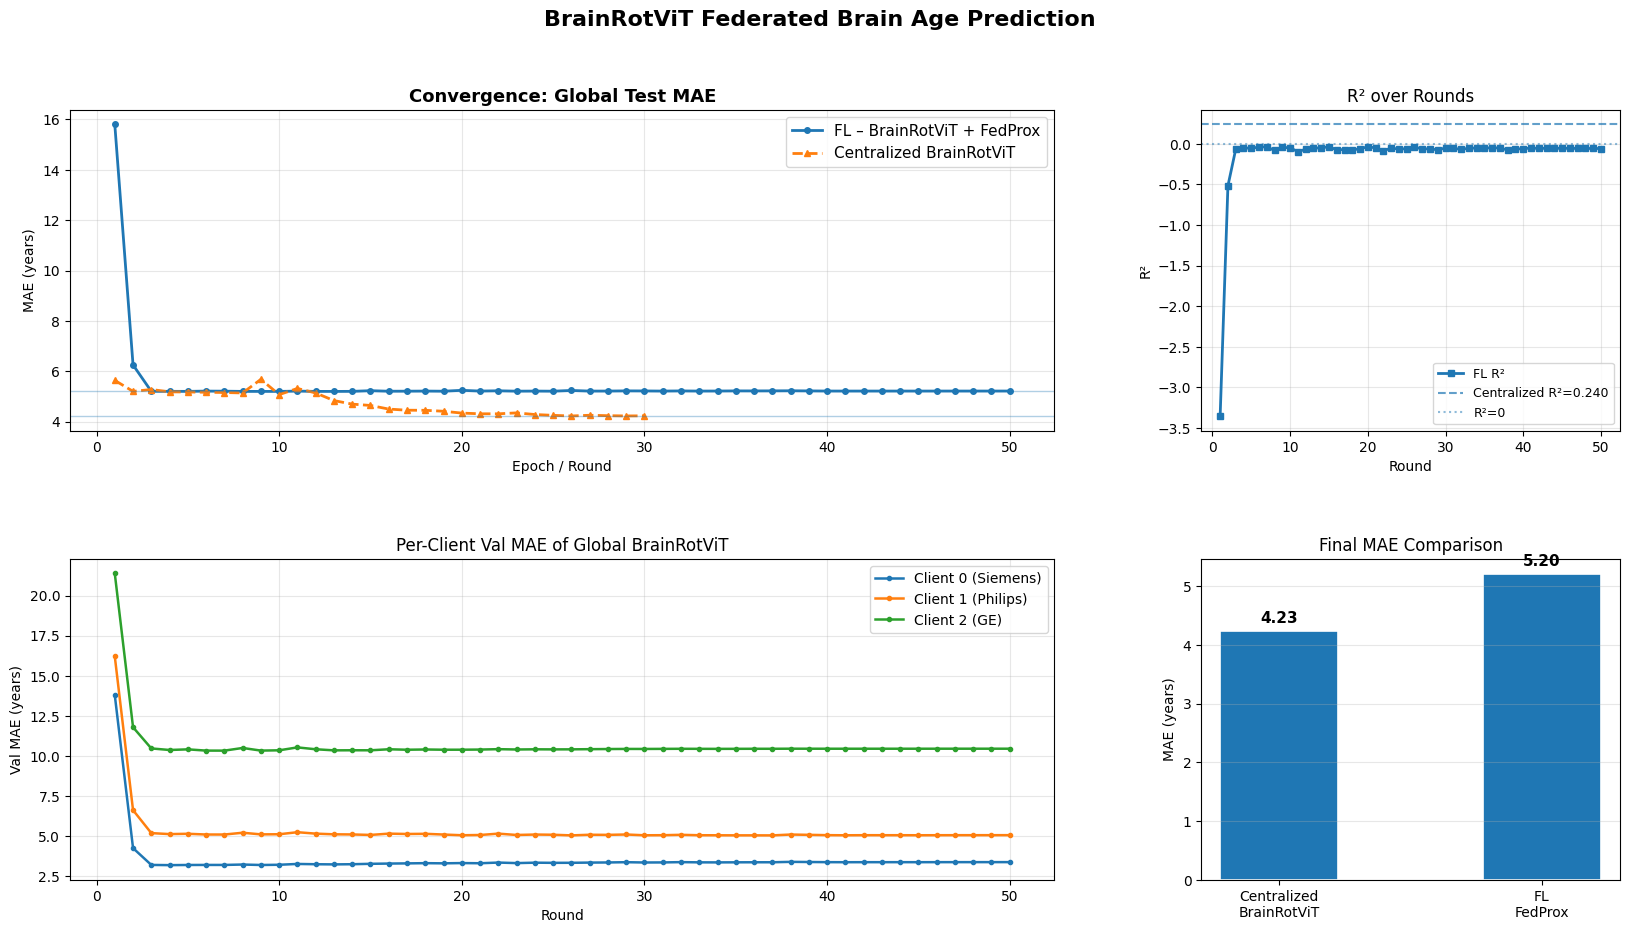

Saved → /kaggle/working/brainrotvit_fedprox_results.png


In [12]:
rounds = fl_history["round"]

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
if len(rounds) > 0:
    ax1.plot(rounds, fl_history["global_mae"], "o-", lw=2, ms=4, label="FL – BrainRotViT + FedProx")
ax1.plot(central_history["epoch"], central_history["mae"], "^--", lw=2, ms=4, label="Centralized BrainRotViT")
ax1.axhline(central_mae, alpha=0.35, lw=1)
ax1.axhline(fl_mae, alpha=0.35, lw=1)
ax1.set_title("Convergence: Global Test MAE", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch / Round")
ax1.set_ylabel("MAE (years)")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
if len(rounds) > 0:
    ax2.plot(rounds, fl_history["global_r2"], "s-", lw=2, ms=4, label="FL R²")
ax2.axhline(central_r2, ls="--", alpha=0.7, label=f"Centralized R²={central_r2:.3f}")
ax2.axhline(0, ls=":", alpha=0.5, label="R²=0")
ax2.set_title("R² over Rounds", fontsize=12)
ax2.set_xlabel("Round")
ax2.set_ylabel("R²")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, :2])
for cid in range(NUM_CLIENTS):
    if len(rounds) > 0:
        ax3.plot(
            rounds,
            fl_history["per_client_mae"][cid],
            "o-",
            lw=1.8,
            ms=3,
            label=f"Client {cid} ({SCANNER_NAMES.get(cid, str(cid))})",
        )
ax3.set_title("Per-Client Val MAE of Global BrainRotViT", fontsize=12)
ax3.set_xlabel("Round")
ax3.set_ylabel("Val MAE (years)")
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
names = ["Centralized\nBrainRotViT", "FL\nFedProx"]
maes = [central_mae, fl_mae]
bars = ax4.bar(names, maes, edgecolor="white", lw=1.2, width=0.45)
ax4.bar_label(bars, fmt="%.2f", padding=4, fontsize=11, fontweight="bold")
ax4.set_title("Final MAE Comparison", fontsize=12)
ax4.set_ylabel("MAE (years)")
ax4.grid(True, axis="y", alpha=0.3)

plt.suptitle("BrainRotViT Federated Brain Age Prediction", fontsize=16, fontweight="bold")
plt.savefig("/kaggle/working/brainrotvit_fedprox_results.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved → /kaggle/working/brainrotvit_fedprox_results.png")